# Global Freelancer Segmentation — Exploratory Data Analysis

**Dataset:** [Freelancer Earnings & Job Trends](https://www.kaggle.com/datasets/shohinurpervezshohan/freelancer-earnings-and-job-trends) (Kaggle)

This notebook explores the raw dataset before any modeling decisions are made:
distribution shapes, missing values, outliers, and relationships between the
fields that end up driving the segmentation (earnings, hourly rate, success
rate, client rating, rehire rate).

Run `train_pipeline.py` separately to produce the final model used by the
Streamlit app — this notebook is for exploration only.

In [9]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src.data_preprocessing import load_raw_data, clean_data

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load raw data

Download the CSV from Kaggle first and place it in `data/raw/`.

In [2]:
RAW_PATH = Path("../data/raw/freelancer_earnings_and_job_trends.csv")
raw_df = load_raw_data(RAW_PATH)
raw_df.head()

INFO | Loaded raw data: 1950 rows, 15 columns


,Freelancer_ID,Job_Category,Platform,Experience_Level,Client_Region,Payment_Method,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Project_Type,Rehire_Rate,Marketing_Spend
0,1,Web Development,Fiverr,Beginner,Asia,Mobile Banking,180,1620,95.79,68.73,3.18,1,Fixed,40.19,53
1,2,App Development,Fiverr,Beginner,Australia,Mobile Banking,218,9078,86.38,97.54,3.44,54,Fixed,36.53,486
2,3,Web Development,Fiverr,Beginner,UK,Crypto,27,3455,85.17,86.60,4.20,46,Hourly,74.05,489
3,4,Data Entry,PeoplePerHour,Intermediate,Asia,Bank Transfer,17,5577,14.37,79.93,4.47,41,Hourly,27.58,67
4,5,Digital Marketing,Upwork,Expert,Asia,Crypto,245,5898,99.37,57.80,5.00,41,Hourly,69.09,489


In [3]:
raw_df.info()
print()
print("Missing values per column:")
print(raw_df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1950 entries, 0 to 1949
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Freelancer_ID      1950 non-null   int64  
 1   Job_Category       1950 non-null   str    
 2   Platform           1950 non-null   str    
 3   Experience_Level   1950 non-null   str    
 4   Client_Region      1950 non-null   str    
 5   Payment_Method     1950 non-null   str    
 6   Job_Completed      1950 non-null   int64  
 7   Earnings_USD       1950 non-null   int64  
 8   Hourly_Rate        1950 non-null   float64
 9   Job_Success_Rate   1950 non-null   float64
 10  Client_Rating      1950 non-null   float64
 11  Job_Duration_Days  1950 non-null   int64  
 12  Project_Type       1950 non-null   str    
 13  Rehire_Rate        1950 non-null   float64
 14  Marketing_Spend    1950 non-null   int64  
dtypes: float64(4), int64(5), str(6)
memory usage: 228.6 KB

Missing values per column:


## 2. Clean the data

Using the same `clean_data` function the production pipeline uses, so the EDA reflects reality.

In [4]:
df = clean_data(raw_df)
print(f"Rows before cleaning: {len(raw_df)}  |  after cleaning: {len(df)}")
df.describe()

INFO | Cleaned data: 1950 -> 1950 rows (0 removed)


Rows before cleaning: 1950  |  after cleaning: 1950


,Freelancer_ID,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Rehire_Rate,Marketing_Spend
count,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000
mean,975.500000,150.864103,5017.541846,52.580788,74.951846,3.995892,44.704615,44.556913,248.518974
std,563.060832,85.480770,2925.378747,26.908740,14.615735,0.575976,26.022998,20.193842,148.005056
min,1.000000,5.000000,119.960000,6.234700,50.160000,3.000000,1.000000,10.000000,5.000000
25%,488.250000,76.000000,2419.000000,30.047500,61.917500,3.510000,22.000000,27.150000,119.000000
50%,975.500000,149.000000,5048.000000,52.285000,75.400000,3.990000,45.000000,43.920000,252.500000
75%,1462.750000,225.000000,7608.250000,75.125000,87.537500,4.500000,67.000000,61.690000,379.000000
max,1950.000000,299.000000,9937.020000,98.815100,99.990000,5.000000,89.000000,79.950000,495.000000


## 3. Distributions of key numeric fields

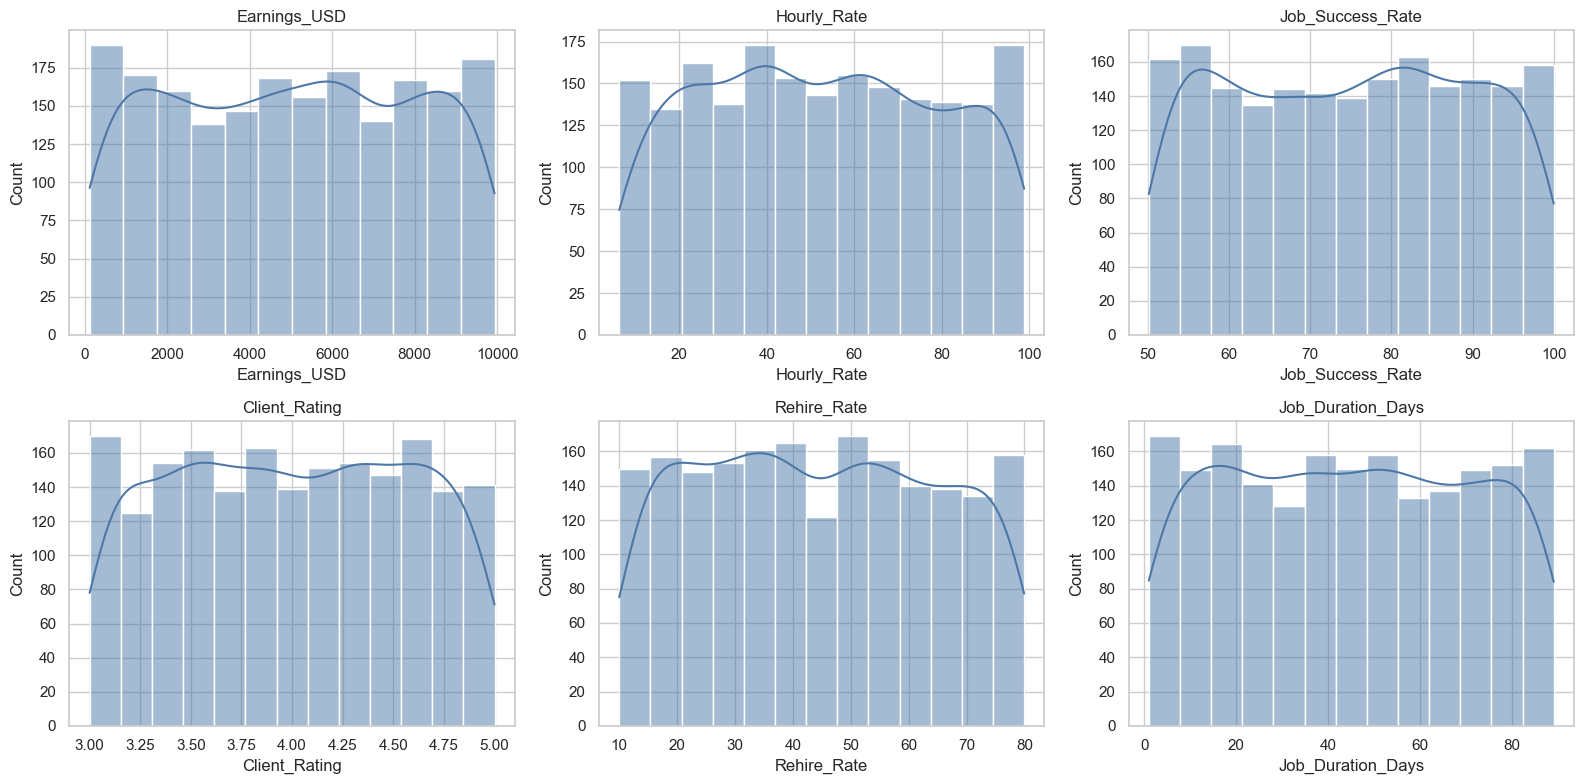

In [5]:
numeric_cols = ["Earnings_USD", "Hourly_Rate", "Job_Success_Rate",
                "Client_Rating", "Rehire_Rate", "Job_Duration_Days"]
numeric_cols = [c for c in numeric_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C78A8")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Categorical breakdowns — platform, experience level, client region

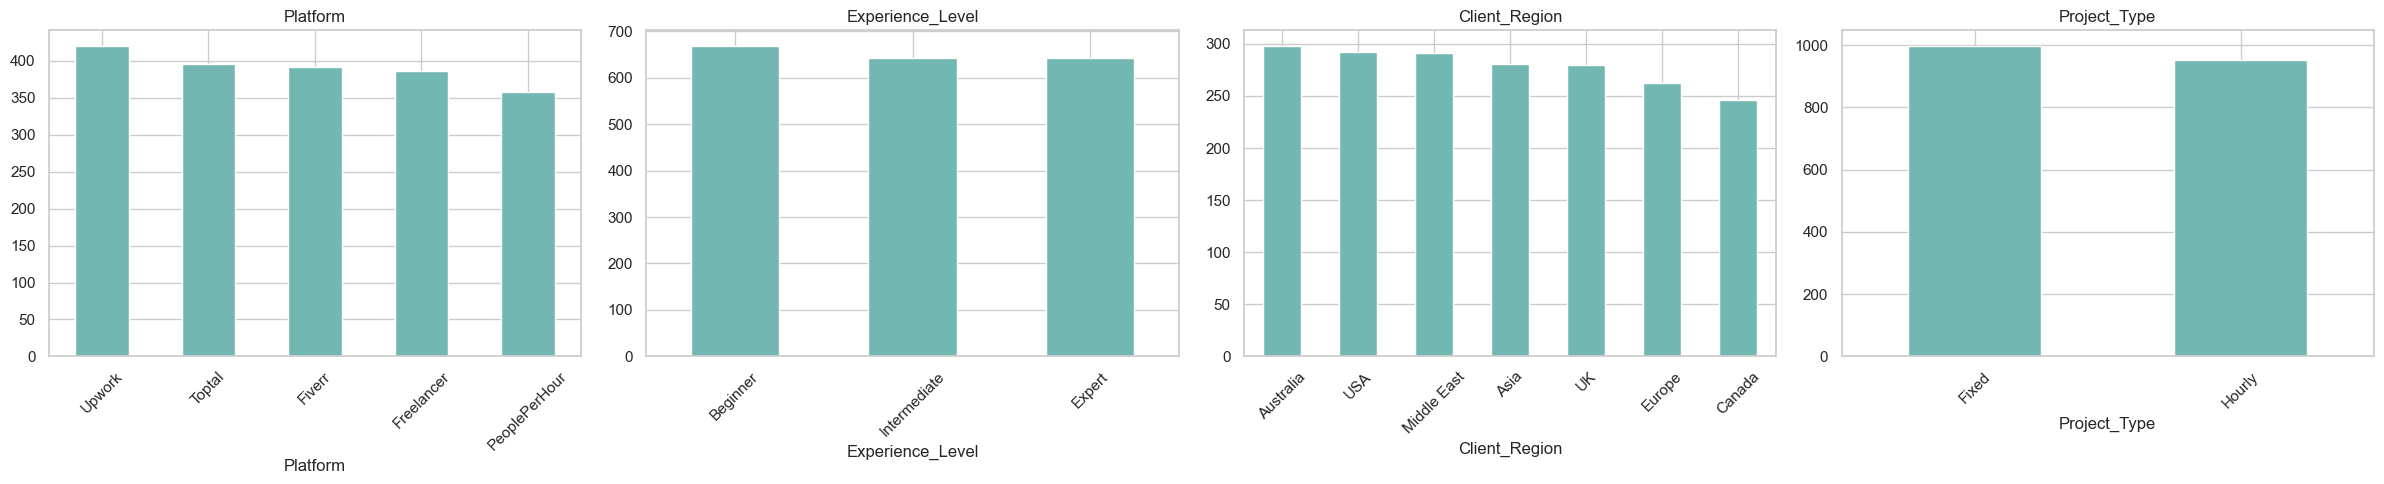

In [6]:
cat_cols = [c for c in ["Platform", "Experience_Level", "Client_Region", "Project_Type"] if c in df.columns]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))
if len(cat_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind="bar", ax=ax, color="#72B7B2")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 5. Correlation between numeric features

This informs which engineered features are worth adding before clustering (see `src/feature_engineering.py`).

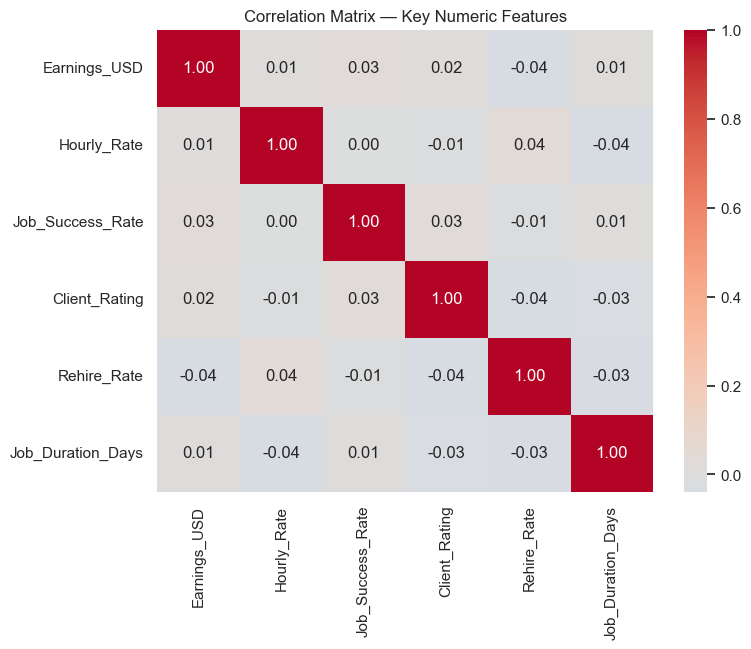

In [7]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix — Key Numeric Features")
plt.show()

## 6. Earnings by platform and experience level

A first look at whether platform choice or experience level alone explains
earnings — spoiler: not fully, which is exactly why clustering on a
combination of behavioral features (see the main pipeline) is more useful
than a single groupby.

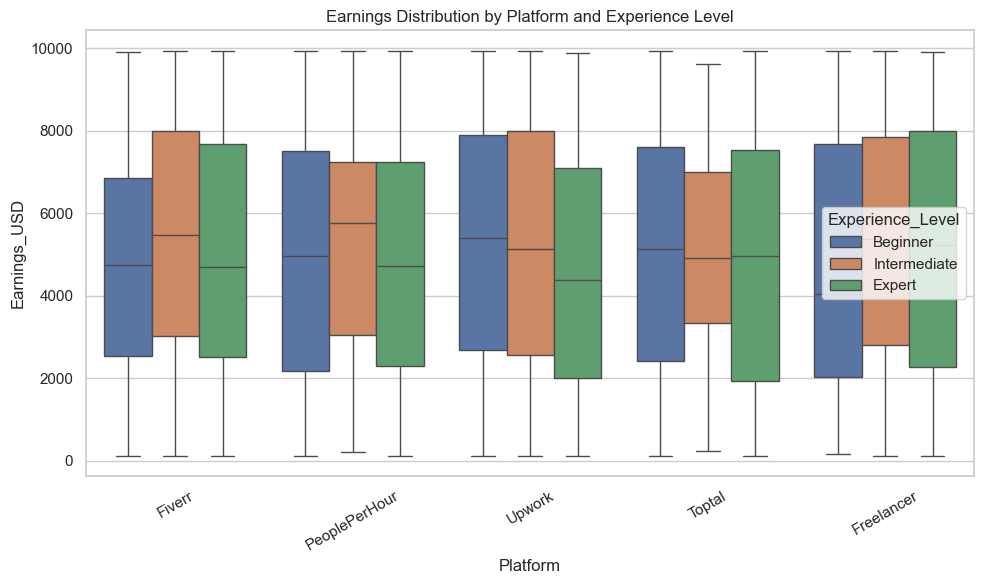

In [8]:
if "Platform" in df.columns and "Experience_Level" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x="Platform", y="Earnings_USD", hue="Experience_Level")
    plt.xticks(rotation=30)
    plt.title("Earnings Distribution by Platform and Experience Level")
    plt.tight_layout()
    plt.show()

## Next step

Feature engineering and clustering happen in `src/feature_engineering.py`
and `src/clustering.py`. Run:

```bash
python train_pipeline.py
```

from the project root to produce the segmented dataset and trained model
used by the Streamlit app.